# In-Class Assignment 05/21/26
**Name:** Christine Wu

In [1]:
# notebook for building CNN with cats & dogs dataset

In [2]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import image_dataset_from_directory
import pandas as pd
from pathlib import Path
import random

### Importing the raw cat and dog images

In [3]:
# importing the data (cat and dog images)

data_dir = "/Users/christinewu/Desktop/academic resources/Advanced Machine Learning/In-Class Assignment Files/cats_dogs"

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # resize ALL images to 128x128 (so all same shape)
    batch_size=32                               # number of images per batch
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio as training set
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same resizing as training set
    batch_size=32                               # same batch size as training set
)

raw_class_names = sorted([path.name for path in Path(data_dir).iterdir() if path.is_dir()])
raw_preview_paths = sorted([str(path) for class_dir in Path(data_dir).iterdir() if class_dir.is_dir() for path in class_dir.glob("*")])

import gc
del train_ds_raw, val_ds_raw
_ = gc.collect()

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


#### To check if tf can access any GPU you have on your machine

In [4]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU detected and available for TensorFlow.")
else:
    print("No GPU detected. Training will use CPU.")

No GPU detected. Training will use CPU.


In [5]:
# View labels from the first training batch

label_lookup = {name: i for i, name in enumerate(raw_class_names)}
first_batch_paths = raw_preview_paths[:32]
sample_path_for_normalization = first_batch_paths[0]
first_batch_labels = np.array([label_lookup[Path(path).parent.name] for path in first_batch_paths])

print(first_batch_labels)
print(raw_class_names)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
['cats_set', 'dogs_set']


In [6]:
# class names
class_names = raw_class_names
print(class_names)

['cats_set', 'dogs_set']


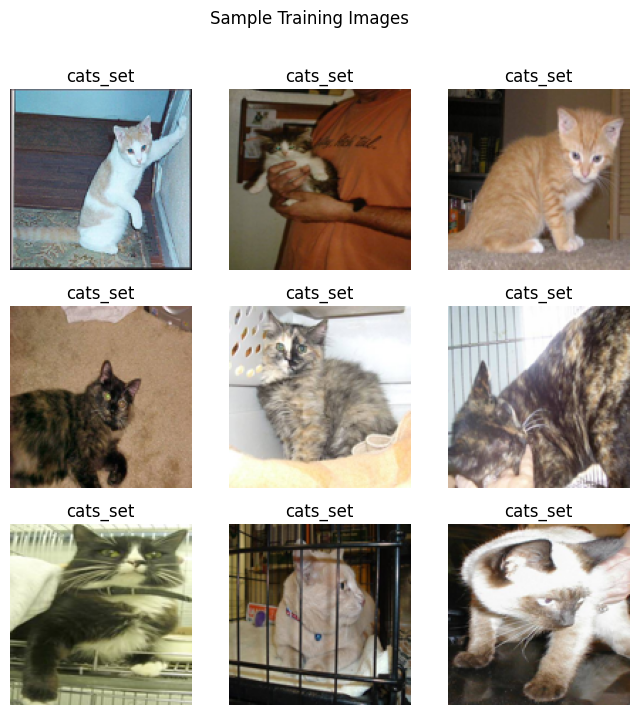

In [7]:
# View one batch of images
from PIL import Image

plt.figure(figsize=(8, 8))

for i, path in enumerate(raw_preview_paths[:9]):
    with Image.open(path) as opened_img:
        img = np.asarray(opened_img.convert("RGB").resize((128, 128)))
    label = Path(path).parent.name
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.suptitle("Sample Training Images")
plt.show()
plt.close()

### Importing padded cat and dog images

In [8]:
# Re-import images with aspect-ratio preservation (padded instead of raw)

train_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # root folder containing class subfolders
    validation_split=0.2,                       # use 20% of data for validation
    subset="training",                          # select the training portion
    seed=42,                                    # ensures consistent train/validation split
    image_size=(128, 128),                      # target size for all images
    batch_size=32,                              # number of images per batch
    pad_to_aspect_ratio=True                    # preserve image proportions and pad instead of stretching
)

val_ds_padded = tf.keras.utils.image_dataset_from_directory(
    data_dir,                                   # same dataset location
    validation_split=0.2,                       # same split ratio
    subset="validation",                        # select the validation portion
    seed=42,                                    # must match training split
    image_size=(128, 128),                      # same target size
    batch_size=32,                              # same batch size
    pad_to_aspect_ratio=True                    # apply same preprocessing to validation data
)

# Split validation into validation + test (50/50 split)
val_batches = tf.data.experimental.cardinality(val_ds_padded).numpy()

test_ds_padded = val_ds_padded.take(val_batches // 2)
val_ds_padded = val_ds_padded.skip(val_batches // 2)

print("Train batches:", tf.data.experimental.cardinality(train_ds_padded).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds_padded).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds_padded).numpy())

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Train batches: 25
Validation batches: 4
Test batches: 3


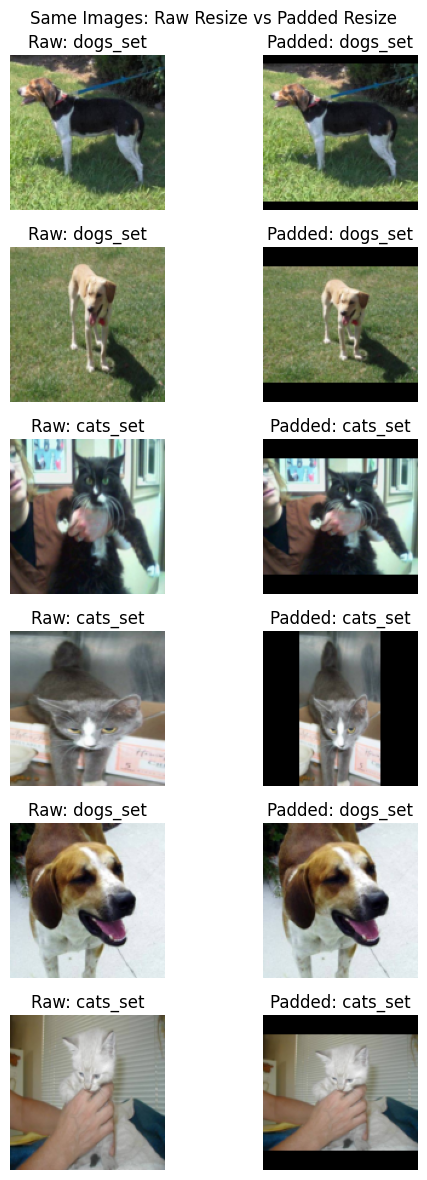

In [9]:
random.seed(42)
from PIL import Image, ImageOps

cat_paths = list(Path(data_dir).glob("cats_set/*"))
dog_paths = list(Path(data_dir).glob("dogs_set/*"))

image_paths = random.sample(cat_paths, 3) + random.sample(dog_paths, 3)
random.shuffle(image_paths)

resample = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR

plt.figure(figsize=(6, 12))

for i, path in enumerate(image_paths):
    with Image.open(path) as opened_img:
        img = opened_img.convert("RGB")
        raw_img = np.asarray(img.resize((128, 128), resample=resample))
        padded_img = np.asarray(ImageOps.pad(img, (128, 128), method=resample, color=(0, 0, 0)))
    label = path.parent.name

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(raw_img)
    plt.title(f"Raw: {label}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(padded_img)
    plt.title(f"Padded: {label}")
    plt.axis("off")

plt.suptitle("Same Images: Raw Resize vs Padded Resize")
plt.tight_layout()
plt.show()
plt.close()

### Normalize all data and shuffle train data

In [10]:
# Normalize pixel values from 0–255 to 0–1 for all datasets
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_padded = train_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # normalize images; keep labels unchanged
)

val_ds_padded = val_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to validation data
)

test_ds_padded = test_ds_padded.map(
    lambda x, y: (normalization_layer(x), y)     # apply same normalization to test data
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds_padded = train_ds_padded.cache()
val_ds_padded = val_ds_padded.cache()
test_ds_padded = test_ds_padded.cache()

# Shuffle only the training data to improve learning 
# Did above but best practice to do after all preprocessing steps
train_ds_padded = train_ds_padded.shuffle(
    1000,                                        # buffer size (>= dataset size for good mixing)
    seed=42                                      # ensures reproducible shuffling
)

train_ds_padded = train_ds_padded.prefetch(AUTOTUNE)
val_ds_padded = val_ds_padded.prefetch(AUTOTUNE)
test_ds_padded = test_ds_padded.prefetch(AUTOTUNE)

In [11]:
# check normalization worked correctly (should be 0–1 range)
from PIL import Image
with Image.open(sample_path_for_normalization) as opened_img:
    sample_img = np.asarray(opened_img.convert("RGB").resize((128, 128)))
sample_normalized = sample_img.astype("float32") / 255.0
print(sample_normalized.min(), sample_normalized.max())

import gc
try:
    del train_ds_raw, val_ds_raw
except NameError:
    pass
_ = gc.collect()

0.02745098 1.0


### Building the MLP model

In [12]:
# set random seed for reproducibility
tf.random.set_seed(42)  

# Define the MLP model
mlp_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),       # input is a 128x128 color image
    layers.Flatten(),                        # convert image to a 1D vector (loses spatial structure)
    layers.Dense(128, activation="relu"),    # hidden layer learns patterns from pixel values
    layers.Dense(64, activation="relu"),     # deeper representation of patterns
    layers.Dense(1, activation="sigmoid")    # output: probability of one class (binary classification)
])

# Compile the model
mlp_catdog.compile(
    optimizer="adam",                        # optimization algorithm
    loss="binary_crossentropy",              # loss for binary classification
    metrics=["accuracy"]                     # track accuracy during training
)

# summary of the MLP model architecture
mlp_catdog.summary()



Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 6,299,905 (24.03 MB)
 Trainable params: 6,299,905 (24.03 MB)
 Non-trainable params: 0 (0.00 B)


In [13]:
# train the MLP model
mlp_history = mlp_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=10,
    verbose=2
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_catdog.evaluate(test_ds_padded, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10
25/25 - 1s - 60ms/step - accuracy: 0.5500 - loss: 2.2039 - val_accuracy: 0.6250 - val_loss: 0.8289
Epoch 2/10
25/25 - 1s - 26ms/step - accuracy: 0.5913 - loss: 0.8338 - val_accuracy: 0.5288 - val_loss: 1.1563
Epoch 3/10
25/25 - 1s - 28ms/step - accuracy: 0.5763 - loss: 0.8805 - val_accuracy: 0.4712 - val_loss: 1.3600
Epoch 4/10
25/25 - 1s - 25ms/step - accuracy: 0.5913 - loss: 0.8297 - val_accuracy: 0.5481 - val_loss: 0.7593
Epoch 5/10
25/25 - 1s - 26ms/step - accuracy: 0.6762 - loss: 0.6015 - val_accuracy: 0.4904 - val_loss: 0.8069
Epoch 6/10
25/25 - 1s - 27ms/step - accuracy: 0.7163 - loss: 0.5460 - val_accuracy: 0.5385 - val_loss: 0.7890
Epoch 7/10
25/25 - 1s - 28ms/step - accuracy: 0.6988 - loss: 0.6159 - val_accuracy: 0.6154 - val_loss: 0.9507
Epoch 8/10
25/25 - 1s - 26ms/step - accuracy: 0.6200 - loss: 0.8702 - val_accuracy: 0.5096 - val_loss: 0.8428
Epoch 9/10
25/25 - 1s - 26ms/step - accuracy: 0.7038 - loss: 0.6436 - val_accuracy: 0.5096 - val_loss: 0.9904
Epoch 10/1

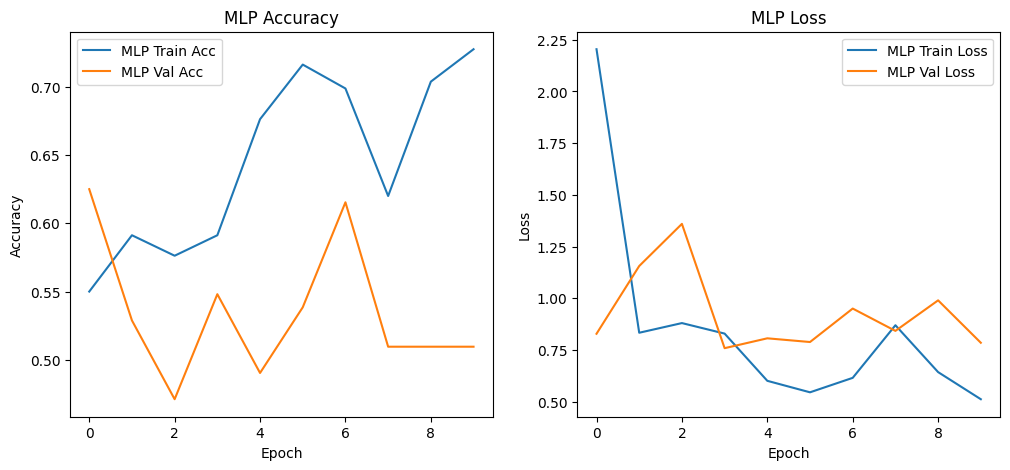

In [14]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], label='MLP Train Acc')
plt.plot(mlp_history.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], label='MLP Train Loss')
plt.plot(mlp_history.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


### Building CNN model

In [15]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    verbose=2
)

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")

Epoch 1/20
25/25 - 4s - 172ms/step - accuracy: 0.5375 - loss: 0.9723 - val_accuracy: 0.5962 - val_loss: 0.6801
Epoch 2/20
25/25 - 4s - 141ms/step - accuracy: 0.6062 - loss: 0.6608 - val_accuracy: 0.5673 - val_loss: 0.6879
Epoch 3/20
25/25 - 4s - 140ms/step - accuracy: 0.6837 - loss: 0.6134 - val_accuracy: 0.4904 - val_loss: 0.7070
Epoch 4/20
25/25 - 4s - 142ms/step - accuracy: 0.7387 - loss: 0.5358 - val_accuracy: 0.5673 - val_loss: 0.7224
Epoch 5/20
25/25 - 4s - 143ms/step - accuracy: 0.7638 - loss: 0.4923 - val_accuracy: 0.5192 - val_loss: 0.7649
Epoch 6/20
25/25 - 4s - 146ms/step - accuracy: 0.8213 - loss: 0.4140 - val_accuracy: 0.6058 - val_loss: 0.7621
Epoch 7/20
25/25 - 4s - 155ms/step - accuracy: 0.8850 - loss: 0.3252 - val_accuracy: 0.5673 - val_loss: 0.8091
Epoch 8/20
25/25 - 4s - 162ms/step - accuracy: 0.9262 - loss: 0.2309 - val_accuracy: 0.5673 - val_loss: 0.9394
Epoch 9/20
25/25 - 4s - 155ms/step - accuracy: 0.9488 - loss: 0.1609 - val_accuracy: 0.5577 - val_loss: 1.1213
E

### Visualizing CNN performance

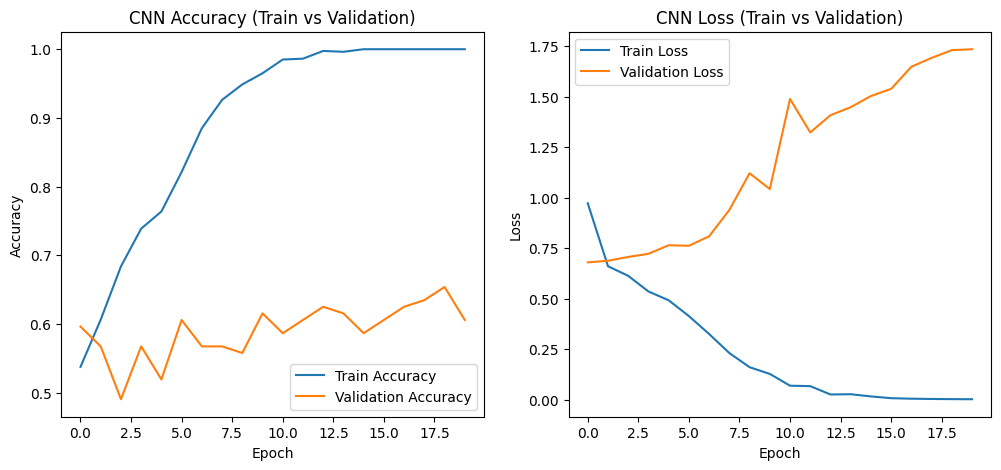

In [16]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### CNN with early stopping

In [17]:
# add early stopping to CNN model
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",                         # watch validation loss
    patience=5,                                 # stop if no improvement for 5 epochs
    restore_best_weights=True                   # revert to best model after stopping
)

# set random seed for reproducibility
tf.random.set_seed(42)

# define the CNN model
cnn_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),             # input: 128x128 RGB image

    layers.Conv2D(32, (3, 3), activation="relu", 
                  padding="same"),                 # detect edges / simple patterns
    layers.MaxPooling2D((2, 2)),                   # reduce spatial size

    layers.Conv2D(64, (3, 3), activation="relu", 
                  padding="same"),                 # detect more complex patterns
    layers.MaxPooling2D((2, 2)),                   # further reduce size

    layers.Flatten(),                              # convert feature maps to vector
    layers.Dense(64, activation="relu"),           # combine features
    layers.Dense(1, activation="sigmoid")          # binary output (cat vs dog)
])

# Compile CNN model
cnn_catdog.compile(
    optimizer="adam",                              # optimization algorithm
    loss="binary_crossentropy",                    # binary classification loss
    metrics=["accuracy"]                           # track accuracy
)

# Train CNN model
cnn_history = cnn_catdog.fit(
    train_ds_padded,                               # training dataset
    validation_data=val_ds_padded,                 # validation dataset
    epochs=20,                                     # increase if needed
    callbacks=[early_stopping],                    # add early stopping callback
    verbose=2
)                   

# Evaluate CNN on test set (unseen data)
cnn_test_loss, cnn_test_acc = cnn_catdog.evaluate(test_ds_padded)

print(f"CNN test accuracy: {cnn_test_acc:.4f}")


Epoch 1/20
25/25 - 5s - 203ms/step - accuracy: 0.5675 - loss: 0.7500 - val_accuracy: 0.5962 - val_loss: 0.6878
Epoch 2/20
25/25 - 4s - 171ms/step - accuracy: 0.6137 - loss: 0.6517 - val_accuracy: 0.5673 - val_loss: 0.6982
Epoch 3/20
25/25 - 4s - 173ms/step - accuracy: 0.6862 - loss: 0.6050 - val_accuracy: 0.5000 - val_loss: 0.7275
Epoch 4/20
25/25 - 5s - 181ms/step - accuracy: 0.7212 - loss: 0.5197 - val_accuracy: 0.5385 - val_loss: 0.6971
Epoch 5/20
25/25 - 5s - 200ms/step - accuracy: 0.7638 - loss: 0.4623 - val_accuracy: 0.5481 - val_loss: 0.7635
Epoch 6/20
25/25 - 5s - 185ms/step - accuracy: 0.8687 - loss: 0.3318 - val_accuracy: 0.6154 - val_loss: 0.6917

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4688 - loss: 0.7080
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5078 - loss: 0.6969
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accurac

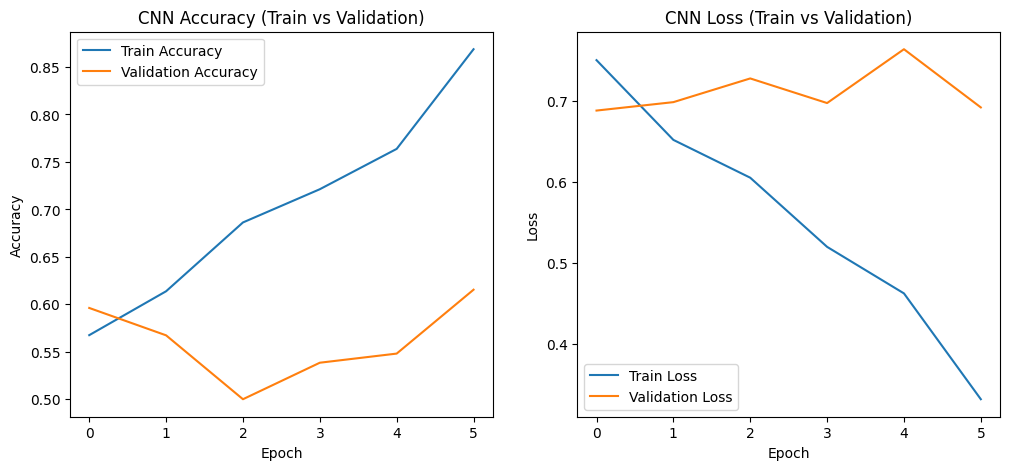

In [18]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history["loss"], label="Train Loss")
plt.plot(cnn_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

plt.show()

### Does CNN performance improve with data augmentation?

In [19]:
# set random seed for reproducibility
tf.random.set_seed(42)

# define data augmentation
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

# define CNN model with data augmentation
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),          # input: 128x128 RGB image

    data_augmentation,                          # apply augmentation during training only

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# compile augmented CNN model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# train augmented CNN model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    verbose=2
)

# evaluate augmented CNN on test set
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 - 6s - 221ms/step - accuracy: 0.5250 - loss: 0.9691 - val_accuracy: 0.5962 - val_loss: 0.6736
Epoch 2/20
25/25 - 5s - 187ms/step - accuracy: 0.5813 - loss: 0.6677 - val_accuracy: 0.5192 - val_loss: 0.6948
Epoch 3/20
25/25 - 5s - 182ms/step - accuracy: 0.6150 - loss: 0.6515 - val_accuracy: 0.5385 - val_loss: 0.7034
Epoch 4/20
25/25 - 5s - 185ms/step - accuracy: 0.6562 - loss: 0.6236 - val_accuracy: 0.6250 - val_loss: 0.6853
Epoch 5/20
25/25 - 5s - 197ms/step - accuracy: 0.6775 - loss: 0.5996 - val_accuracy: 0.6154 - val_loss: 0.6447
Epoch 6/20
25/25 - 5s - 183ms/step - accuracy: 0.6687 - loss: 0.6140 - val_accuracy: 0.6538 - val_loss: 0.6466
Epoch 7/20
25/25 - 5s - 190ms/step - accuracy: 0.7075 - loss: 0.5734 - val_accuracy: 0.6827 - val_loss: 0.6486
Epoch 8/20
25/25 - 5s - 187ms/step - accuracy: 0.7212 - loss: 0.5567 - val_accuracy: 0.7308 - val_loss: 0.6337
Epoch 9/20
25/25 - 5s - 185ms/step - accuracy: 0.7312 - loss: 0.5315 - val_accuracy: 0.6731 - val_loss: 0.6272
E

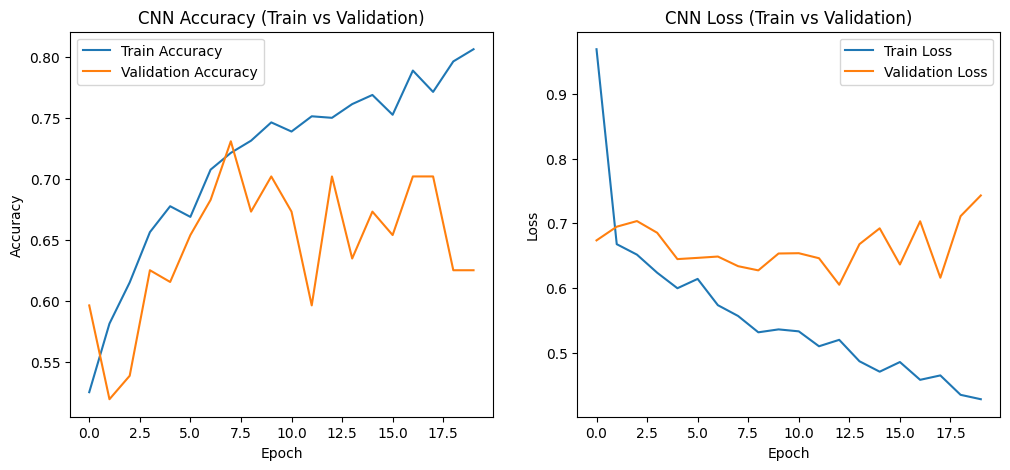

In [20]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code for you to experiment with

Use the code cell below as a starting point. Train at least 3 different CNN models by changing augmentation, regularization, and/or model capacity. Examples include adding rotation, zoom, L2 regularization, dropout, or another convolutional layer. Compare training, validation, and test performance, and explain which model generalizes best.

In [21]:
# Try different augmentation choices
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    # layers.RandomRotation(0.05),
    # layers.RandomZoom(0.05),
    # layers.RandomTranslation(0.05, 0.05),
    # layers.RandomContrast(0.1)
])

# Early stopping
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Set random seed for reproducibility
tf.random.set_seed(42)

# Define CNN model with experimentation options
cnn_aug_catdog = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    # First convolution block
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional Batch Normalization
    # layers.BatchNormalization(),

    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),

    # Optional added capacity
    # layers.Conv2D(
    #     128, (3, 3),
    #     padding="same",
    #     # kernel_regularizer=regularizers.l2(0.0005)
    # ),
    # # layers.BatchNormalization(),
    # layers.Activation("relu"),
    # layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu",
        # kernel_regularizer=regularizers.l2(0.0005)
    ),

    # Optional dropout
    # layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid")
])

# Compile model
cnn_aug_catdog.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
cnn_aug_history = cnn_aug_catdog.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=20,
    callbacks=[early_stopping_aug],
    verbose=2
)

# Evaluate model
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_catdog.evaluate(test_ds_padded)

print(f"Augmented CNN test accuracy: {cnn_aug_test_acc:.4f}")

Epoch 1/20
25/25 - 5s - 212ms/step - accuracy: 0.5512 - loss: 0.7871 - val_accuracy: 0.6058 - val_loss: 0.6858
Epoch 2/20
25/25 - 5s - 185ms/step - accuracy: 0.5888 - loss: 0.6746 - val_accuracy: 0.6154 - val_loss: 0.6738
Epoch 3/20
25/25 - 5s - 194ms/step - accuracy: 0.5875 - loss: 0.6653 - val_accuracy: 0.6250 - val_loss: 0.6866
Epoch 4/20
25/25 - 5s - 212ms/step - accuracy: 0.6187 - loss: 0.6426 - val_accuracy: 0.5769 - val_loss: 0.7016
Epoch 5/20
25/25 - 5s - 189ms/step - accuracy: 0.6538 - loss: 0.6115 - val_accuracy: 0.5865 - val_loss: 0.7152
Epoch 6/20
25/25 - 5s - 185ms/step - accuracy: 0.7100 - loss: 0.5651 - val_accuracy: 0.5288 - val_loss: 0.7046
Epoch 7/20
25/25 - 5s - 185ms/step - accuracy: 0.7275 - loss: 0.5274 - val_accuracy: 0.6154 - val_loss: 0.6970

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5312 - loss: 0.7049
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5547 - loss: 0.6927

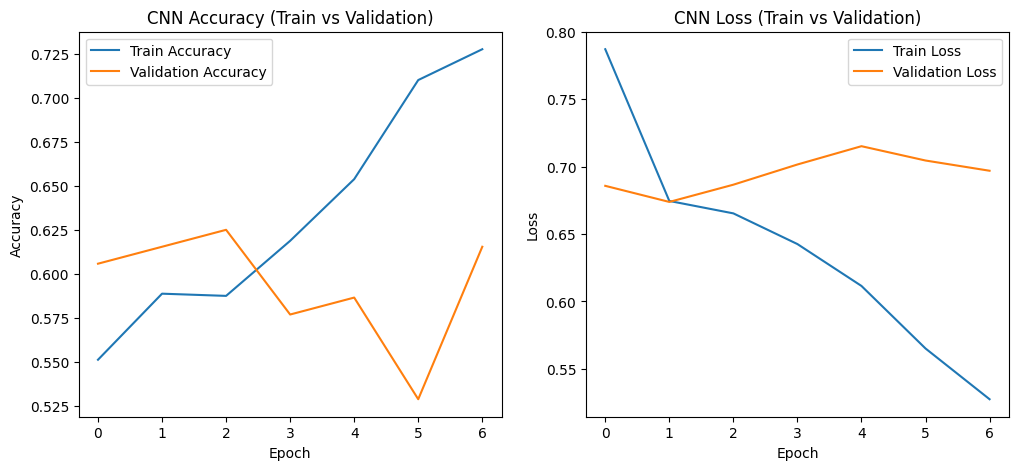

In [22]:
# visualizing train vs validation accuracy for CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(cnn_aug_history.history["accuracy"], label="Train Accuracy")
plt.plot(cnn_aug_history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy (Train vs Validation)")
plt.legend()

# plot train vs validation loss for CNN model
plt.subplot(1, 2, 2)
plt.plot(cnn_aug_history.history["loss"], label="Train Loss")
plt.plot(cnn_aug_history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss (Train vs Validation)")
plt.legend()

plt.show()

### Code cells for your 3+ models. Make sure to annotate for each, explaining what you tried

**Experiment 1:** This model tests moderate augmentation with L2 regularization, dropout, batch normalization, and global average pooling. The goal is to reduce overfitting while keeping the model small.

Epoch 1/25
25/25 - 9s - 370ms/step - accuracy: 0.5550 - loss: 0.7483 - val_accuracy: 0.5385 - val_loss: 0.7427
Epoch 2/25
25/25 - 8s - 315ms/step - accuracy: 0.6037 - loss: 0.7192 - val_accuracy: 0.5385 - val_loss: 0.7400
Epoch 3/25
25/25 - 8s - 310ms/step - accuracy: 0.6087 - loss: 0.7089 - val_accuracy: 0.5385 - val_loss: 0.7395
Epoch 4/25
25/25 - 8s - 316ms/step - accuracy: 0.6488 - loss: 0.7015 - val_accuracy: 0.5385 - val_loss: 0.7360
Epoch 5/25
25/25 - 8s - 309ms/step - accuracy: 0.6237 - loss: 0.6964 - val_accuracy: 0.5385 - val_loss: 0.7350
Epoch 6/25
25/25 - 8s - 309ms/step - accuracy: 0.6525 - loss: 0.6819 - val_accuracy: 0.5385 - val_loss: 0.7302
Epoch 7/25
25/25 - 8s - 318ms/step - accuracy: 0.6575 - loss: 0.6722 - val_accuracy: 0.5385 - val_loss: 0.7308
Epoch 8/25
25/25 - 8s - 311ms/step - accuracy: 0.6488 - loss: 0.6687 - val_accuracy: 0.5385 - val_loss: 0.7302
Epoch 9/25
25/25 - 8s - 318ms/step - accuracy: 0.6575 - loss: 0.6772 - val_accuracy: 0.5481 - val_loss: 0.7165
E

,model,epochs_run,final_train_accuracy,final_validation_accuracy,best_validation_accuracy,best_validation_loss,test_accuracy,test_loss
0,Moderate augmentation + L2 + dropout + batch norm,21,0.6687,0.5577,0.7115,0.6524,0.6979,0.6531


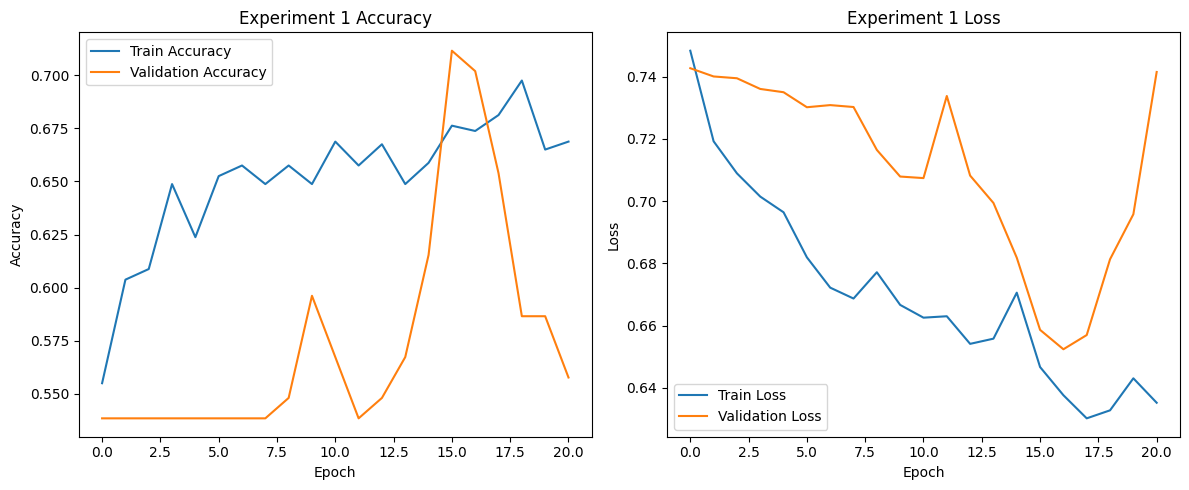

In [23]:
from IPython.display import display, Markdown

experiment_results = []

def plot_experiment_history(history, title):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

def summarize_experiment(name, history, test_loss, test_acc):
    result = {
        "model": name,
        "epochs_run": len(history.history["loss"]),
        "final_train_accuracy": history.history["accuracy"][-1],
        "final_validation_accuracy": history.history["val_accuracy"][-1],
        "best_validation_accuracy": max(history.history["val_accuracy"]),
        "best_validation_loss": min(history.history["val_loss"]),
        "test_accuracy": test_acc,
        "test_loss": test_loss
    }
    experiment_results.append(result)
    display(pd.DataFrame(experiment_results).round(4))
    return result

display(Markdown("**Experiment 1:** This model tests moderate augmentation with L2 regularization, dropout, batch normalization, and global average pooling. The goal is to reduce overfitting while keeping the model small."))

tf.random.set_seed(42)

exp1_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.04),
    layers.RandomZoom(0.08)
])

exp1_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    exp1_augmentation,
    layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.0005)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.25),
    layers.Dense(1, activation="sigmoid")
])

exp1_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

exp1_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

exp1_history = exp1_model.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=25,
    callbacks=[exp1_early_stopping],
    verbose=2
)

exp1_test_loss, exp1_test_acc = exp1_model.evaluate(test_ds_padded, verbose=0)
print(f"Experiment 1 test accuracy: {exp1_test_acc:.4f}")
plot_experiment_history(exp1_history, "Experiment 1")
summarize_experiment("Moderate augmentation + L2 + dropout + batch norm", exp1_history, exp1_test_loss, exp1_test_acc)

**Experiment 2:** This model tests a higher capacity CNN with a third convolution block, stronger augmentation, dropout, and a lower learning rate. The goal is to see whether more filters improve validation performance.

Epoch 1/30
25/25 - 14s - 544ms/step - accuracy: 0.4750 - loss: 3.2304 - val_accuracy: 0.5481 - val_loss: 0.6899
Epoch 2/30
25/25 - 12s - 472ms/step - accuracy: 0.5437 - loss: 0.6842 - val_accuracy: 0.5962 - val_loss: 0.6867
Epoch 3/30
25/25 - 12s - 479ms/step - accuracy: 0.5650 - loss: 0.6756 - val_accuracy: 0.4615 - val_loss: 0.6932
Epoch 4/30
25/25 - 13s - 522ms/step - accuracy: 0.5125 - loss: 0.6849 - val_accuracy: 0.4615 - val_loss: 0.6926
Epoch 5/30
25/25 - 12s - 485ms/step - accuracy: 0.5312 - loss: 0.6673 - val_accuracy: 0.5769 - val_loss: 0.6925
Epoch 6/30
25/25 - 12s - 493ms/step - accuracy: 0.5825 - loss: 0.6558 - val_accuracy: 0.5192 - val_loss: 0.6866
Epoch 7/30
25/25 - 13s - 538ms/step - accuracy: 0.5913 - loss: 0.6595 - val_accuracy: 0.4615 - val_loss: 0.6933
Epoch 8/30
25/25 - 13s - 502ms/step - accuracy: 0.5725 - loss: 0.6590 - val_accuracy: 0.5385 - val_loss: 0.6930
Epoch 9/30
25/25 - 13s - 528ms/step - accuracy: 0.5550 - loss: 0.6616 - val_accuracy: 0.5288 - val_loss:

,model,epochs_run,final_train_accuracy,final_validation_accuracy,best_validation_accuracy,best_validation_loss,test_accuracy,test_loss
0,Moderate augmentation + L2 + dropout + batch norm,21,0.6687,0.5577,0.7115,0.6524,0.6979,0.6531
1,Higher capacity + stronger augmentation + dropout,24,0.6438,0.6154,0.7596,0.5941,0.7396,0.6022


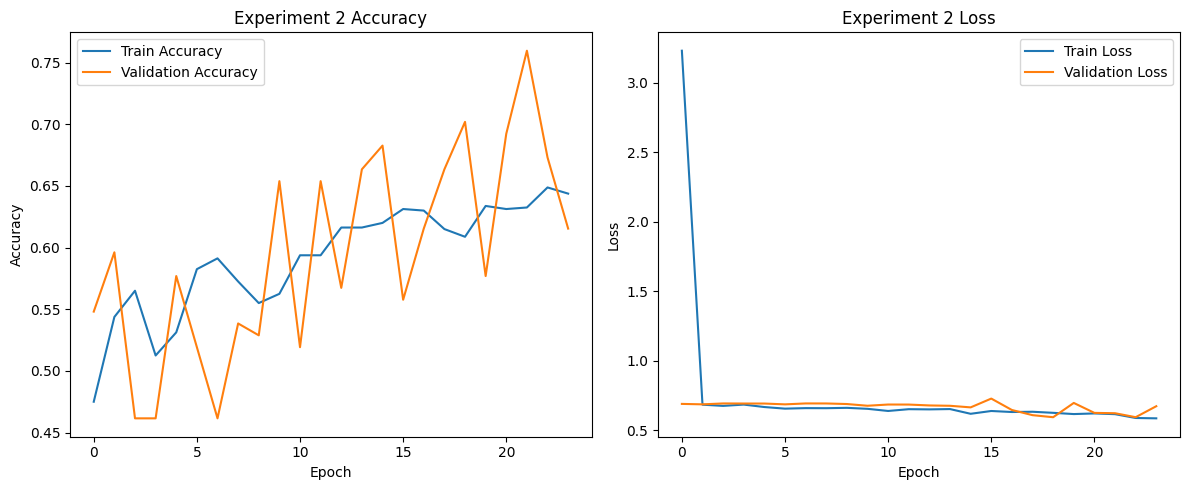

In [24]:
display(Markdown("**Experiment 2:** This model tests a higher capacity CNN with a third convolution block, stronger augmentation, dropout, and a lower learning rate. The goal is to see whether more filters improve validation performance."))

tf.random.set_seed(43)

exp2_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.12),
    layers.RandomTranslation(0.08, 0.08),
    layers.RandomContrast(0.10)
])

exp2_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    exp2_augmentation,
    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.35),
    layers.Dense(1, activation="sigmoid")
])

exp2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

exp2_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

exp2_history = exp2_model.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=30,
    callbacks=[exp2_early_stopping],
    verbose=2
)

exp2_test_loss, exp2_test_acc = exp2_model.evaluate(test_ds_padded, verbose=0)
print(f"Experiment 2 test accuracy: {exp2_test_acc:.4f}")
plot_experiment_history(exp2_history, "Experiment 2")
summarize_experiment("Higher capacity + stronger augmentation + dropout", exp2_history, exp2_test_loss, exp2_test_acc)

**Experiment 3:** This model tests a deeper regularized CNN with stacked convolution blocks, spatial dropout, global average pooling, L2 regularization, and stronger dropout. The goal is to compare a more regularized design against the earlier models.

Epoch 1/30
25/25 - 29s - 1s/step - accuracy: 0.5400 - loss: 1.0605 - val_accuracy: 0.5385 - val_loss: 1.0404
Epoch 2/30
25/25 - 28s - 1s/step - accuracy: 0.5663 - loss: 1.0464 - val_accuracy: 0.5385 - val_loss: 1.0313
Epoch 3/30
25/25 - 27s - 1s/step - accuracy: 0.5612 - loss: 1.0306 - val_accuracy: 0.5385 - val_loss: 1.0257
Epoch 4/30
25/25 - 26s - 1s/step - accuracy: 0.6037 - loss: 0.9991 - val_accuracy: 0.5385 - val_loss: 1.0208
Epoch 5/30
25/25 - 26s - 1s/step - accuracy: 0.6150 - loss: 0.9865 - val_accuracy: 0.5385 - val_loss: 1.0157
Epoch 6/30
25/25 - 26s - 1s/step - accuracy: 0.6225 - loss: 0.9767 - val_accuracy: 0.5385 - val_loss: 1.0082
Epoch 7/30
25/25 - 25s - 1s/step - accuracy: 0.6363 - loss: 0.9591 - val_accuracy: 0.5481 - val_loss: 1.0021
Epoch 8/30
25/25 - 25s - 1s/step - accuracy: 0.6025 - loss: 0.9679 - val_accuracy: 0.5385 - val_loss: 0.9922
Epoch 9/30
25/25 - 25s - 1s/step - accuracy: 0.6325 - loss: 0.9490 - val_accuracy: 0.5577 - val_loss: 0.9845
Epoch 10/30
25/25 -

,model,epochs_run,final_train_accuracy,final_validation_accuracy,best_validation_accuracy,best_validation_loss,test_accuracy,test_loss
0,Moderate augmentation + L2 + dropout + batch norm,21,0.6687,0.5577,0.7115,0.6524,0.6979,0.6531
1,Higher capacity + stronger augmentation + dropout,24,0.6438,0.6154,0.7596,0.5941,0.7396,0.6022
2,Deeper regularized CNN + spatial dropout + GAP,28,0.6963,0.6250,0.7115,0.8298,0.7396,0.8223


,model,epochs_run,final_train_accuracy,final_validation_accuracy,best_validation_accuracy,best_validation_loss,test_accuracy,test_loss
0,Moderate augmentation + L2 + dropout + batch norm,21,0.6687,0.5577,0.7115,0.6524,0.6979,0.6531
1,Higher capacity + stronger augmentation + dropout,24,0.6438,0.6154,0.7596,0.5941,0.7396,0.6022
2,Deeper regularized CNN + spatial dropout + GAP,28,0.6963,0.6250,0.7115,0.8298,0.7396,0.8223


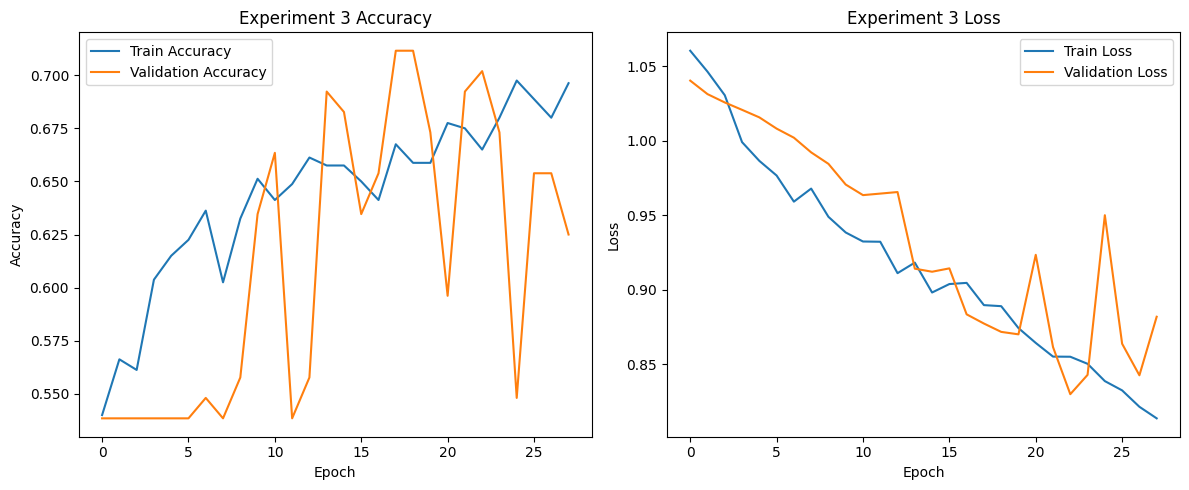

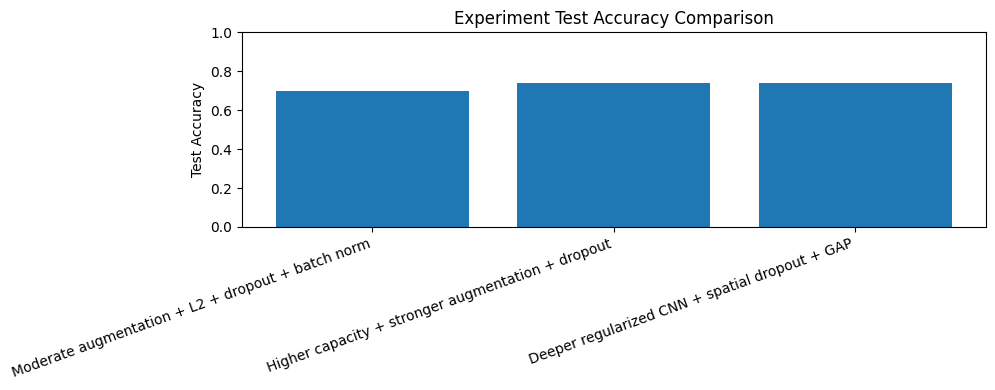

In [25]:
display(Markdown("**Experiment 3:** This model tests a deeper regularized CNN with stacked convolution blocks, spatial dropout, global average pooling, L2 regularization, and stronger dropout. The goal is to compare a more regularized design against the earlier models."))

tf.random.set_seed(44)

exp3_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05)
])

exp3_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    exp3_augmentation,
    layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(32, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.10),
    layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Conv2D(64, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.SpatialDropout2D(0.15),
    layers.Conv2D(128, (3, 3), padding="same", kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.40),
    layers.Dense(1, activation="sigmoid")
])

exp3_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0004),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

exp3_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

exp3_history = exp3_model.fit(
    train_ds_padded,
    validation_data=val_ds_padded,
    epochs=30,
    callbacks=[exp3_early_stopping],
    verbose=2
)

exp3_test_loss, exp3_test_acc = exp3_model.evaluate(test_ds_padded, verbose=0)
print(f"Experiment 3 test accuracy: {exp3_test_acc:.4f}")
plot_experiment_history(exp3_history, "Experiment 3")
summarize_experiment("Deeper regularized CNN + spatial dropout + GAP", exp3_history, exp3_test_loss, exp3_test_acc)

results_df = pd.DataFrame(experiment_results).round(4)
display(results_df)

plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["test_accuracy"])
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.title("Experiment Test Accuracy Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### What seemed to help model performance most in your experiments?

The best test performance was a tie between Experiment 2 and Experiment 3. Both reached a test accuracy of 0.7396.

Experiment 2 is the stronger choice overall because it reached the same test accuracy with a less complex model and shorter training time. The higher capacity helped when it was paired with stronger augmentation, dropout, batch normalization, and a lower learning rate.

Experiment 3 also generalized well, but it trained much more slowly. The deeper architecture and heavier regularization made training more stable, but they also slowed learning.

The plain CNN overfit the most. Training accuracy reached 1.0000 while validation accuracy stayed much lower. Data augmentation, dropout, L2 regularization, batch normalization, and early stopping helped reduce overfitting and made validation performance more stable.